In [1]:
from google.colab import files
uploaded = files.upload()

Saving credit_card_fraud.csv to credit_card_fraud.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('credit_card_fraud.csv')
df.head()

,V1,V2,V3,V4,V5,Amount,Class
0,0.543360,-0.193659,0.968185,-0.213457,0.285803,55.271583,0.0
1,0.982691,0.808058,0.885231,1.352203,1.272570,39.268121,0.0
2,-1.840874,-0.223466,1.954157,-1.435910,-0.992866,275.345272,0.0
3,-0.573662,0.579633,1.809306,0.596441,-0.453636,405.983871,0.0
4,-1.124642,0.536653,-0.929511,1.190549,-0.546042,108.890401,0.0


In [5]:
df.shape

(1000, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      1000 non-null   float64
 1   V2      1000 non-null   float64
 2   V3      1000 non-null   float64
 3   V4      1000 non-null   float64
 4   V5      1000 non-null   float64
 5   Amount  1000 non-null   float64
 6   Class   1000 non-null   float64
dtypes: float64(7)
memory usage: 54.8 KB


In [7]:
df.describe()

,V1,V2,V3,V4,V5,Amount,Class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.022887,0.061579,0.003728,-0.020524,-0.051598,258.849015,0.010000
std,0.975938,1.000535,0.977687,1.013361,0.999238,178.640412,0.099549
min,-3.241267,-2.940389,-3.019512,-2.929449,-3.176704,0.120502,0.000000
25%,-0.637475,-0.608245,-0.648000,-0.737420,-0.691214,125.898334,0.000000
50%,0.026488,0.054298,-0.010695,-0.001359,-0.009567,246.269883,0.000000
75%,0.649083,0.708135,0.666819,0.657407,0.634238,383.157937,0.000000
max,3.852731,3.193108,3.926238,3.243093,3.152057,1916.061917,1.000000


In [8]:
df.isna().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
Amount,0
Class,0


In [9]:
df['Class'].unique()

array([0., 1.])

In [10]:
cols = df.select_dtypes(include='number').drop(columns='Class')

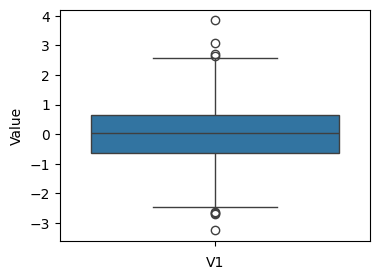

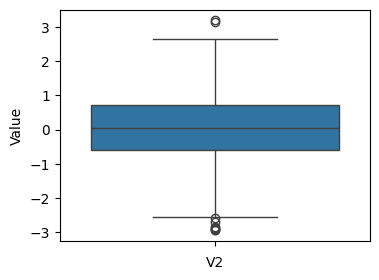

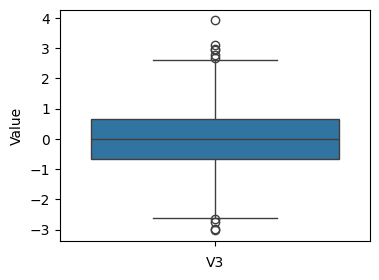

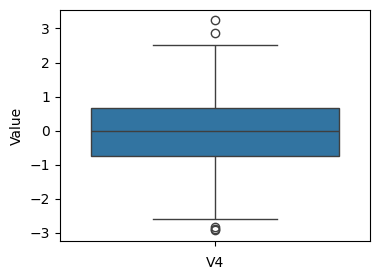

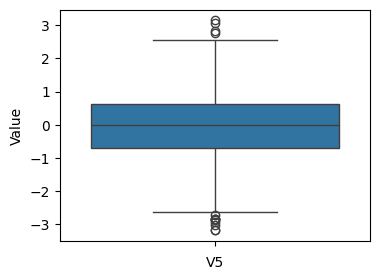

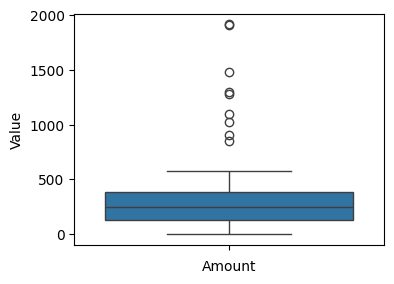

In [11]:
for col in cols:
  plt.figure(figsize=(4,3))
  sns.boxplot(df[col])
  plt.xlabel(col)
  plt.ylabel('Value')
  plt.show()

In [12]:
outliers_cols = []
for col in cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  if outliers.shape[0] > 0:
    outliers_cols.append(col)
    print(f'{col} has : {outliers.shape[0]} outliers')

V1 has : 8 outliers
V2 has : 9 outliers
V3 has : 10 outliers
V4 has : 5 outliers
V5 has : 13 outliers
Amount has : 9 outliers


In [13]:
df_clipped = df.copy()
for col in outliers_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_clipped[col] = df_clipped[col].clip(lower_bound, upper_bound)

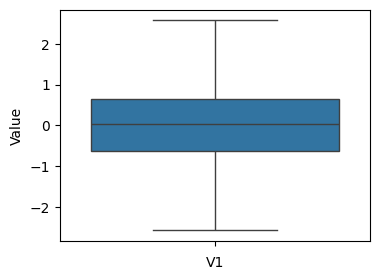

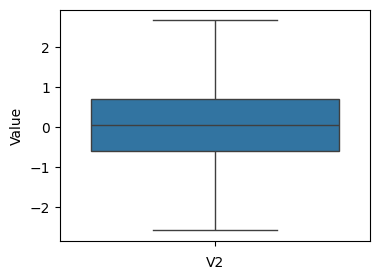

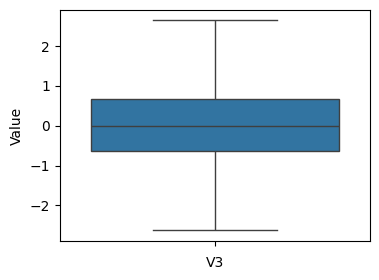

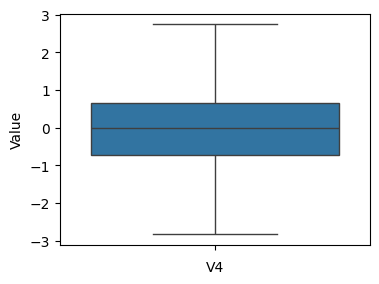

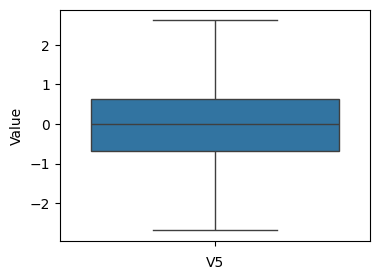

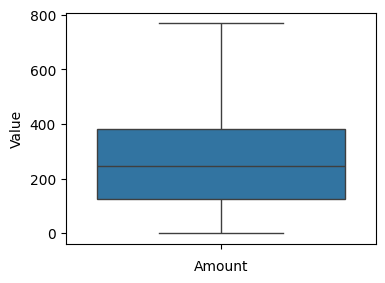

In [14]:
for col in outliers_cols:
  plt.figure(figsize=(4,3))
  sns.boxplot(df_clipped[col])
  plt.xlabel(col)
  plt.ylabel('Value')
  plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [16]:
model = {
    'logistic' : Pipeline([('scaler', StandardScaler()), ('smote', SMOTE(k_neighbors=5, random_state=42)),
                  ('logistic', LogisticRegression())]),

    'dcson_tree' : Pipeline([('smote', SMOTE(k_neighbors=5, random_state=42)), ('decision', DecisionTreeClassifier(random_state=42))]),

    'rndm_forest' : Pipeline([('smote', SMOTE(k_neighbors=5, random_state=42)), ('rndm_forest', RandomForestClassifier(random_state=42))]),

    'knn' : Pipeline([('scaler', StandardScaler()), ('smote', SMOTE(k_neighbors=5, random_state=42)), ('knn', KNeighborsClassifier(n_neighbors=5))]),

    'svc' :Pipeline ([('scaler', StandardScaler()), ('smote', SMOTE(k_neighbors=5, random_state=42)), ('svc', SVC(probability=True, class_weight='balanced'))]),

}

In [17]:
X = df_clipped.drop(['Class'], axis=1)
y = df_clipped['Class']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
for name,mdl in model.items():
  mdl.fit(X_train, y_train)
  y_pred = mdl.predict(X_test)
  print(f'{name} : \n{accuracy_score(y_test, y_pred)}')
  print(f'{name} : \n{confusion_matrix(y_test, y_pred)}')
  print(f'{name} : \n{classification_report(y_test, y_pred)}')
  print('-'*150)

logistic : 
0.995
logistic : 
[[197   1]
 [  0   2]]
logistic : 
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       198
         1.0       0.67      1.00      0.80         2

    accuracy                           0.99       200
   macro avg       0.83      1.00      0.90       200
weighted avg       1.00      0.99      1.00       200

------------------------------------------------------------------------------------------------------------------------------------------------------
dcson_tree : 
1.0
dcson_tree : 
[[198   0]
 [  0   2]]
dcson_tree : 
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       198
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

-------------------------------------------------------------

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
df_clipped['cluster'] = kmeans.fit_predict(X_scaled)

df_clipped['cluster'].value_counts()

,count
cluster,
1,545
0,455


In [21]:
labels = kmeans.labels_
df_clipped['cluster'] = labels

In [22]:
print(pd.crosstab(df_clipped['cluster'], df_clipped['Class']))

Class    0.0  1.0
cluster          
0        447    8
1        543    2


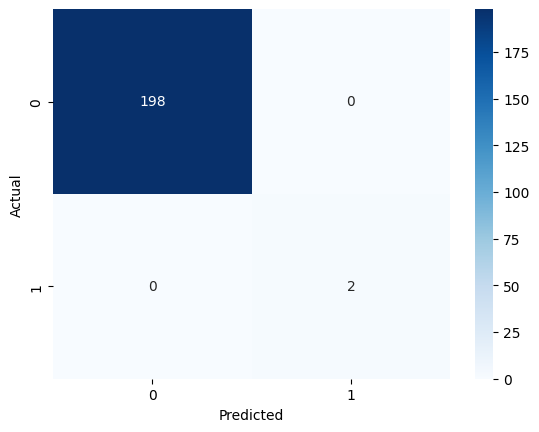

In [23]:
y_pred = model['svc'].predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

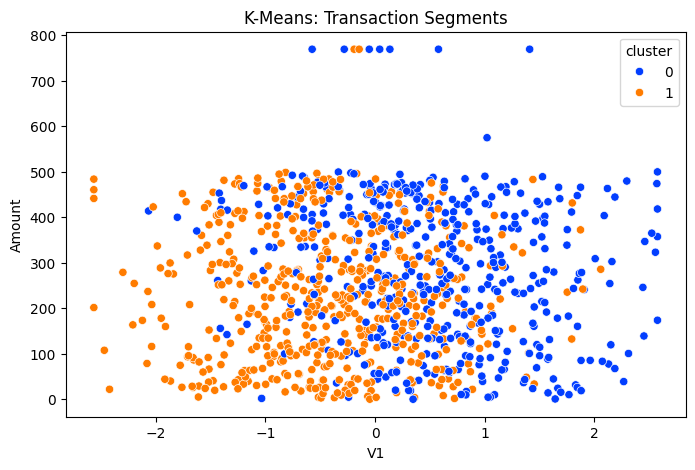

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='V1', y='Amount', hue='cluster', data=df_clipped, palette='bright')
plt.title('K-Means: Transaction Segments')
plt.show()

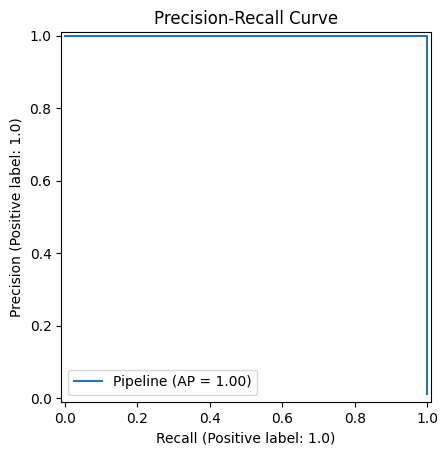

In [25]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(model['svc'], X_test, y_test)
plt.title('Precision-Recall Curve')
plt.show()

In [26]:
new_data = {
    'V1' : [-3.840874, -1.155879],
    'V2' : [1.223466, 2.338908],
    'V3' : [6.954157, -0.999987],
    'V4' : [-5.435910, 2.556324],
    'V5' : [-2.992866, 2.998765],
    'Amount' : [575.345272, 685.874389]

}

In [27]:
predicted = model['svc'].predict(pd.DataFrame(new_data))
predicted

array([0., 0.])